# 一. 降雨数据获取示例教程

本教程将演示如何从 Google Earth Engine (GEE) 获取降雨数据，包括：
- **GFS (Global Forecast System)**: 全球天气预报系统数据
- **MSWEP (Multi-Source Weighted-Ensemble Precipitation)**: 多源加权集合降雨数据

## 数据获取思路

### 1. 流域准备
- 你需要准备流域 shapefile 文件, 这里统一使用Google Flood的shapefile 文件（包含 5819 个流域）
- 挑选流域ID, 裁剪流域边界
- shapefile 文件在jupterhub服务器上, 路径为: /ftproot/watergpt/shapes/basins.shp
- 如果你选择本地运行，需要流域shp文件又不会下载的话联系@助教获取

### 2. GFS 数据获取
- **GFS 数据集**: `NOAA/GFS0P25` - 0.25度分辨率的全球预报数据

#### 方法一：官网下载
- 从官网访问(需要科学上网): https://developers.google.com/earth-engine/datasets/catalog/NOAA_GFS0P25?hl=zh-cn 

#### 方法二：使用GEE下载
Google Earth Engine (GEE) 是一个强大的地理空间分析平台，提供海量卫星和气象数据集；
- 需要申请一个 Google 账号，并开通 Google Drive 云盘
- 需要在 GEE 控制台创建一个你的项目 https://code.earthengine.google.com/

### 3. MSWEP 数据获取
MSWEP (Multi-Source Weighted-Ensemble Precipitation) 是一个融合多源观测的降雨数据集

#### 方法一：官网下载
- 官网 https://www.gloh2o.org/mswep/
- 点击进入并填写必要的申请信息，提交申请后，会收到一封确认邮件，邮件中包含数据下载链接（Google云盘链接）
- 需要申请Google Drive的访问权限，获取链接后也需要自己有Google Drive账号
- 比如这个链接：https://drive.google.com/drive/folders/1Kok05OPVESTpyyan7NafR-2WwuSJ4TO9?usp=drive_link

可以选择手动从云盘下载到本地，推荐使用**rclone**下载更快捷
#### 方法二：访问水资源所的服务器下载
- 访问水资源所的 **jupyterhub** 服务器：http://jupyterhub.waterism.com:666/
- 目前只有mswep的3h尺度数据，路径为：/ftproot/mswep_3h


## 1. 导入必要的库

In [6]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
import json
import warnings
import random
import time, datetime as dt
from pathlib import Path
import math
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
import rasterio
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("所有库导入成功！")

所有库导入成功！


## 2. 读取流域 Shapefile

查看项目中包含的流域数据，展示流域总数和基本信息。

In [ ]:
shapefile_path = "/ftproot/watergpt/shapes/basins.shp"  # 这里是服务器上的路径，请根据实际路径调整

try:
    basins_gdf = gpd.read_file(shapefile_path)
    
    print(f"成功读取流域数据！")
    print(f"流域总数: {len(basins_gdf)}")
    print(f"\n流域数据前5行：")
    print(basins_gdf.head())
    
    # 显示字段信息
    print(f"\n字段列表: {list(basins_gdf.columns)}")
    print(f"坐标系统: {basins_gdf.crs}")
    
except FileNotFoundError:
    print(f"错误: 找不到文件 {shapefile_path}")
    print("请确保 shapefile 文件已放置在 shape/ 目录下")
except Exception as e:
    print(f"读取 shapefile 时出错: {e}")

成功读取流域数据！
流域总数: 5819

流域数据前5行：
          BASIN_ID          AREA  \
0   anhui_62909400    497.103823   
1  changdian_60650  14818.479819   
2  changdian_60668   4481.930930   
3  changdian_61239   3385.442446   
4  changdian_61277   1771.092026   

                                            geometry  
0  POLYGON ((118.64794 30.39353, 118.64793 30.392...  
1  POLYGON ((103.89586 28.08094, 103.89677 28.080...  
2  POLYGON ((104.2199 27.77011, 104.22021 27.7701...  
3  POLYGON ((103.54905 29.15324, 103.54874 29.153...  
4  POLYGON ((104.41872 29.7712, 104.41996 29.7712...  

字段列表: ['BASIN_ID', 'AREA', 'geometry']
坐标系统: EPSG:4326


## 3. 随机选择流域

从 5819 个流域中随机选择流域，这里作为示例选一个流域

随机选择了 1 个流域
流域索引: [5238]

选中的流域信息:
  1. 流域ID: grdc_6503120, 面积: 815.35 km²

示例流域:
  流域ID: grdc_6503120
  流域面积: 815.35 km²
  流域边界 [minx, miny, maxx, maxy]: [-8.8625     52.30833333 -8.275      52.58333333]


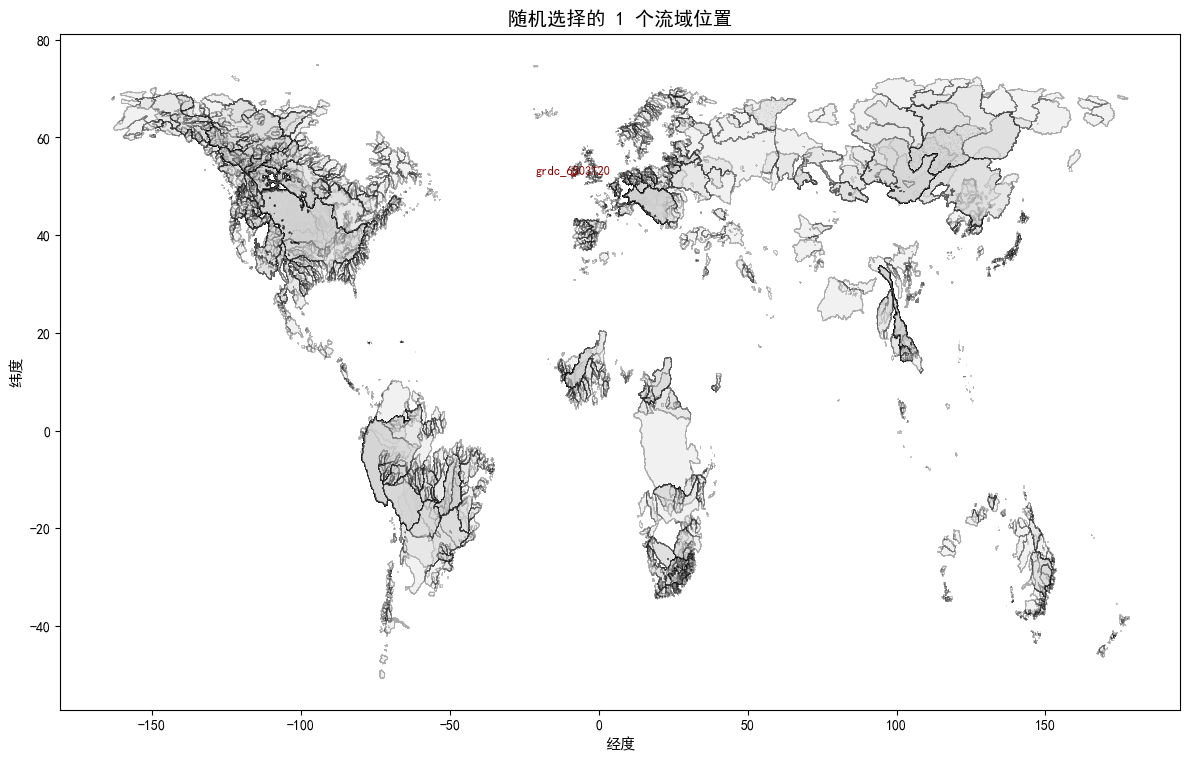


提示: 修改 NUM_BASINS 参数可以选择不同数量的流域


In [4]:
# ============ 自定义选择流域数量 ============
NUM_BASINS = 1  # 选择流域的数量，默认为1

# 设置随机种子以确保可重复性
random.seed(42)

# 从所有流域中随机选择指定数量的流域
if NUM_BASINS > len(basins_gdf):
    print(f"警告: 请求的流域数量 ({NUM_BASINS}) 超过总数 ({len(basins_gdf)})，将选择所有流域")
    NUM_BASINS = len(basins_gdf)

random_indices = random.sample(range(len(basins_gdf)), NUM_BASINS)
selected_basins = basins_gdf.iloc[random_indices].copy()

print(f"随机选择了 {NUM_BASINS} 个流域")
print(f"流域索引: {random_indices}")
print(f"\n选中的流域信息:")
for idx, (i, basin) in enumerate(selected_basins.iterrows()):
    basin_id = basin['BASIN_ID']
    basin_area = basin['AREA']
    print(f"  {idx+1}. 流域ID: {basin_id}, 面积: {basin_area:.2f} km²")

# 如果只选择一个流域，将其设为示例流域
if NUM_BASINS == 1:
    example_basin = selected_basins
    example_basin_id = example_basin['BASIN_ID'].values[0]
    basin_area = example_basin['AREA'].values[0]
    
    print(f"\n示例流域:")
    print(f"  流域ID: {example_basin_id}")
    print(f"  流域面积: {basin_area:.2f} km²")
    
    # 获取流域边界
    basin_bounds = example_basin.total_bounds
    print(f"  流域边界 [minx, miny, maxx, maxy]: {basin_bounds}")
else:
    # 多个流域时，使用第一个作为示例
    example_basin = selected_basins.iloc[0:1]
    example_basin_id = example_basin['BASIN_ID'].values[0]
    basin_area = example_basin['AREA'].values[0]
    
    print(f"\n使用第一个流域作为示例:")
    print(f"  流域ID: {example_basin_id}")
    print(f"  流域面积: {basin_area:.2f} km²")
    
    # 获取流域边界
    basin_bounds = example_basin.total_bounds
    print(f"  流域边界 [minx, miny, maxx, maxy]: {basin_bounds}")

# 可视化流域位置
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
basins_gdf.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.3, linewidth=0.5)
selected_basins.plot(ax=ax, color='red', edgecolor='darkred', linewidth=2, alpha=0.6)

# 标注流域ID
for idx, (i, basin) in enumerate(selected_basins.iterrows()):
    centroid = basin.geometry.centroid
    ax.annotate(basin['BASIN_ID'], xy=(centroid.x, centroid.y), 
                fontsize=9, ha='center', color='darkred', fontweight='bold')

ax.set_title(f'随机选择的 {NUM_BASINS} 个流域位置', fontsize=14, fontweight='bold')
ax.set_xlabel('经度', fontsize=11)
ax.set_ylabel('纬度', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n提示: 修改 NUM_BASINS 参数可以选择不同数量的流域")

## 4. 从 GEE 获取 GFS 降雨数据

GFS (Global Forecast System) 提供全球天气预报数据。我们将下载示例流域 2024 年的 GFS 降雨数据。

**GEE 中的 GFS 数据集**:
- 数据集 ID: `NOAA/GFS0P25` (0.25度分辨率)
- 时间分辨率: 6小时
- 变量: 降水、温度、风速等

### 4.1 初始化 Google Earth Engine

**首次使用需要进行身份认证（需科学上网）**：
- 配置好环境后在本地终端运行 earthengine authenticate
- 如果配置失败再尝试运行 `ee.Authenticate(auth_mode='notebook')` 进行认证
- 认证后会生成凭证文件，后续自动使用

**注意**: 如果已经认证过，可以直接后面的运行 `ee.Initialize()`


In [ ]:
# 确保已有Google账号和GEE项目
# ee.Authenticate(auth_mode='notebook')

**如果因为网络原因失败，可以先尝试下载MSWEP的数据**

In [ ]:
# 初始化 GEE
try:
    ee.Initialize(project='yourprojectname') # 需要在GEE网站上创建你的项目，改为实际项目名
    print("Google Earth Engine 初始化成功！")
except Exception as e:
    print(f"初始化失败: {e}")
    print("请先运行 ee.Authenticate(auth_mode='notebook') 进行认证")

### 4.2 获取流域AOI坐标（支持多流域）

根据选中的流域数量，自动计算合并后的AOI区域。

In [ ]:
# 将 GeoPandas 的几何对象转换为 GEE 的 Geometry
def gdf_to_ee_geometry(gdf):
    """将 GeoDataFrame 转换为 Earth Engine Geometry"""
    geojson = json.loads(gdf.to_json())
    
    if len(geojson['features']) == 1:
        # 单个流域
        coords = geojson['features'][0]['geometry']['coordinates']
        geom_type = geojson['features'][0]['geometry']['type']
        
        if geom_type == 'Polygon':
            return ee.Geometry.Polygon(coords)
        elif geom_type == 'MultiPolygon':
            return ee.Geometry.MultiPolygon(coords)
        else:
            raise ValueError(f"不支持的几何类型: {geom_type}")
    else:
        # 多个流域，创建GeometryCollection或合并
        geometries = []
        for feature in geojson['features']:
            coords = feature['geometry']['coordinates']
            geom_type = feature['geometry']['type']
            
            if geom_type == 'Polygon':
                geometries.append(ee.Geometry.Polygon(coords))
            elif geom_type == 'MultiPolygon':
                geometries.append(ee.Geometry.MultiPolygon(coords))
        
        # 合并所有几何为一个MultiPolygon或使用union
        return ee.Geometry.MultiPolygon([g.coordinates() for g in geometries])

# 转换选中的所有流域为 EE Geometry
print(f"正在转换 {NUM_BASINS} 个流域的几何对象...")
try:
    # 如果是单个流域，使用 example_basin；如果是多个，使用 selected_basins
    if NUM_BASINS == 1:
        basin_geometry = gdf_to_ee_geometry(example_basin)
        print(f"✓ 单个流域几何对象转换成功")
    else:
        basin_geometry = gdf_to_ee_geometry(selected_basins)
        print(f"✓ {NUM_BASINS} 个流域几何对象转换并合并成功")
    
    # 获取合并后的边界
    basin_bounds_ee = basin_geometry.bounds().getInfo()
    print(f"\n合并后的流域范围: {basin_bounds_ee}")
    
except Exception as e:
    print(f"✗ 转换几何对象时出错: {e}")
    raise

# 获取所有选中流域的总外接矩形边界
all_bounds = selected_basins.total_bounds  # [minx, miny, maxx, maxy]
minLon, minLat, maxLon, maxLat = all_bounds

print(f"\n所有选中流域的外接矩形:")
print(f"  经度范围: [{minLon:.6f}, {maxLon:.6f}]")
print(f"  纬度范围: [{minLat:.6f}, {maxLat:.6f}]")
print(f"  跨度: {maxLon - minLon:.6f}° × {maxLat - minLat:.6f}°")

# 按 GFS 0.25° 网格"外扩对齐"
grid = 0.25
def floor_to_grid(x, g=grid):
    return math.floor(x / g) * g
def ceil_to_grid(x, g=grid):
    return math.ceil(x / g) * g

minLon_snap = floor_to_grid(minLon)
minLat_snap = floor_to_grid(minLat)
maxLon_snap = ceil_to_grid(maxLon)
maxLat_snap = ceil_to_grid(maxLat)

# 创建对齐后的AOI矩形
aoi = ee.Geometry.Rectangle([minLon_snap, minLat_snap, maxLon_snap, maxLat_snap], geodesic=False)

print(f"\n网格对齐后的AOI（用于GFS数据导出）:")
print(f"  经度范围: [{minLon_snap:.2f}, {maxLon_snap:.2f}]")
print(f"  纬度范围: [{minLat_snap:.2f}, {maxLat_snap:.2f}]")
print(f"  AOI坐标: {aoi.coordinates().getInfo()}")
print(f"\n✓ AOI区域计算完成，可用于数据下载")

### 4.3 提交GEE下载任务

定义下载降雨数据的参数和函数，支持单个或多个流域的数据下载。

In [ ]:
# ============ 用户参数 ============
START_DATE = "2024-01-01"  # 开始日期
END_DATE   = "2024-01-31"  # 结束日期
SCALE_M = 25000            # 空间分辨率（米）
CRS = "EPSG:4326"          # 坐标系统
# ====================================

# 根据流域数量设置输出文件夹名称
if NUM_BASINS == 1:
    DRIVE_FOLDER = f"GFS_{example_basin_id}"
    LOCAL_OUT_DIR = f"./gfs_data/{example_basin_id}"
else:
    # 多个流域使用时间戳标识
    timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
    DRIVE_FOLDER = f"GFS_{NUM_BASINS}basins_{timestamp}"
    LOCAL_OUT_DIR = f"./gfs_data/{NUM_BASINS}basins_{timestamp}"

print(f"数据下载配置:")
print(f"  时间范围: {START_DATE} 至 {END_DATE}")
print(f"  空间分辨率: {SCALE_M}m")
print(f"  目标流域数: {NUM_BASINS}")
print(f"  Google Drive 文件夹: {DRIVE_FOLDER}")
print(f"  本地输出目录: {LOCAL_OUT_DIR}")

# AOI 与 band
sel_bands = ["total_precipitation_surface"]
aoi_global = ee.Geometry.Rectangle([-180, -90, 180, 90], geodesic=False)

# 辅助函数
def daterange(start_date, end_date):
    """生成日期范围"""
    start = dt.datetime.strptime(start_date, "%Y-%m-%d").date()
    end   = dt.datetime.strptime(end_date, "%Y-%m-%d").date()
    cur = start
    while cur < end:
        yield cur
        cur = cur + dt.timedelta(days=1)

def gdrive_init():
    """初始化Google Drive"""
    gauth = GoogleAuth()
    gauth.LocalWebserverAuth()
    drive = GoogleDrive(gauth)
    return drive

def ensure_drive_folder(drive, folder_name):
    """确保Google Drive文件夹存在"""
    q = f"title = '{folder_name}' and mimeType = 'application/vnd.google-apps.folder' and trashed = false"
    fl = drive.ListFile({'q': q}).GetList()
    if fl:
        return fl[0]['id']
    folder = drive.CreateFile({'title': folder_name, 'mimeType': 'application/vnd.google-apps.folder'})
    folder.Upload()
    return folder['id']

def wait_for_tasks(tasks, poll_sec=30):
    """等待GEE任务完成"""
    while True:
        states = [t.status().get('state', 'UNKNOWN') for t in tasks]
        running = any(s in ('READY', 'RUNNING') for s in states)
        print("[Tasks] 状态统计：", {s: states.count(s) for s in set(states)})
        if not running:
            break
        time.sleep(poll_sec)

print("\n✓ 函数定义完成")

### 4.4 执行GEE数据导出任务

提交任务到Google Earth Engine，数据将保存到Google云盘。

In [ ]:
# 取消下面的注释以初始化Google Drive（需要时）
# drive = gdrive_init()
# drive_folder_id = ensure_drive_folder(drive, DRIVE_FOLDER)
# Path(LOCAL_OUT_DIR).mkdir(parents=True, exist_ok=True)

# GFS预报时间过滤器
forecast_filters = [
    ee.Filter.stringContains('system:index', 'F001'),
    ee.Filter.stringContains('system:index', 'F002'),
    ee.Filter.stringContains('system:index', 'F003'),
    ee.Filter.stringContains('system:index', 'F004'),
    ee.Filter.stringContains('system:index', 'F005'),
    ee.Filter.stringContains('system:index', 'F006'),
]
combined_filter = ee.Filter.Or(*forecast_filters)

# 加载GFS数据集
gfs = ee.ImageCollection("NOAA/GFS0P25").select(sel_bands)
gfs_filtered = gfs.filter(combined_filter)

export_tasks = []
success_count = 0
skip_count = 0

print(f"\n开始提交GEE导出任务...")
print(f"  AOI区域: {NUM_BASINS} 个流域")
print(f"  时间范围: {START_DATE} 至 {END_DATE}")
print("=" * 60)

for d in daterange(START_DATE, END_DATE):
    d0 = d.strftime("%Y-%m-%d")
    d1 = (d + dt.timedelta(days=1)).strftime("%Y-%m-%d")
    
    # 按日期和AOI过滤数据
    col_day = (gfs_filtered.filterDate(d0, d1).filterBounds(aoi))
    size = col_day.size().getInfo()
    
    if size == 0:
        print(f"[{d0}] ⚠ 无影像数据，跳过")
        skip_count += 1
        continue
    
    # 合并当天所有时次的影像
    img_list = col_day.toList(size)
    merged = ee.ImageCollection(img_list).toBands()
    
    # 文件命名
    if NUM_BASINS == 1:
        name = f"gfs_{example_basin_id}_{d.strftime('%Y%m%d')}"
        desc = f"GFS_{example_basin_id}_{d.strftime('%Y%m%d')}"
    else:
        name = f"gfs_{NUM_BASINS}basins_{d.strftime('%Y%m%d')}"
        desc = f"GFS_{NUM_BASINS}basins_{d.strftime('%Y%m%d')}"
    
    # 创建导出任务
    task = ee.batch.Export.image.toDrive(
        image=merged,
        description=desc,
        folder=DRIVE_FOLDER,
        fileNamePrefix=name,
        # region=aoi,  # 使用计算好的AOI区域
        region=aoi_global,  # 或者使用全球的AOI区域
        scale=SCALE_M,
        crs=CRS,
        maxPixels=1e13
    )
    
    task.start()
    export_tasks.append(task)
    success_count += 1
    print(f"[{d0}] ✓ 已提交任务: {desc}")

print("=" * 60)
print(f"\n任务提交完成!")
print(f"  成功提交: {success_count} 个任务")
print(f"  跳过: {skip_count} 天")
print(f"  总计: {success_count + skip_count} 天")
print(f"\n请访问 https://code.earthengine.google.com/tasks 查看任务状态")
print(f"数据将保存到Google Drive的 '{DRIVE_FOLDER}' 文件夹")

## 5. 可视化GFS数据（可选）

下载完成后，可以可视化查看GFS降雨数据。此部分适用于已下载到本地的GeoTIFF文件。

In [ ]:
# ============ 配置 ============
# 修改为实际下载的GeoTIFF文件路径
tif_path = "GFS_tp_daily_2024/gfs_precip_20240101.tif"
# ==============================

try:
    # 1. 读取 GeoTIFF 文件
    with rasterio.open(tif_path) as src:
        data = src.read(1)  # 读取第一波段
        bounds = src.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
        
        print("GFS降雨数据信息:")
        print(f"  栅格大小: {src.width} × {src.height}")
        print(f"  空间范围: {extent}")
        print(f"  坐标系统: {src.crs}")
        print(f"  数据统计: min={np.nanmin(data):.2f}, max={np.nanmax(data):.2f}, mean={np.nanmean(data):.2f}")
    
    # 2. 将无效值屏蔽掉
    data = np.where(data < 0, np.nan, data)
    
    # 3. 绘制降雨分布
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左图: 降雨分布
    ax1 = axes[0]
    im1 = ax1.imshow(data, cmap='Blues', extent=extent, origin='upper', 
                     vmin=0, vmax=np.nanpercentile(data, 95))
    plt.colorbar(im1, ax=ax1, label="降雨量 (mm)")
    ax1.set_title("GFS降雨分布 - 2024-01-01", fontsize=13, fontweight='bold')
    ax1.set_xlabel("经度")
    ax1.set_ylabel("纬度")
    
    # 叠加流域边界
    if NUM_BASINS == 1:
        # 单个流域
        for geom in example_basin.geometry:
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                ax1.plot(x, y, 'r-', linewidth=2, label='流域边界')
            elif geom.geom_type == 'MultiPolygon':
                for poly in geom.geoms:
                    x, y = poly.exterior.xy
                    ax1.plot(x, y, 'r-', linewidth=2)
    else:
        # 多个流域
        for idx, (i, basin) in enumerate(selected_basins.iterrows()):
            geom = basin.geometry
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                ax1.plot(x, y, 'r-', linewidth=2, alpha=0.8)
            elif geom.geom_type == 'MultiPolygon':
                for poly in geom.geoms:
                    x, y = poly.exterior.xy
                    ax1.plot(x, y, 'r-', linewidth=2, alpha=0.8)
    
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 右图: 降雨直方图
    ax2 = axes[1]
    valid_data = data[~np.isnan(data)]
    valid_data = valid_data[valid_data > 0]  # 只显示有降雨的格点
    
    if len(valid_data) > 0:
        ax2.hist(valid_data, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        ax2.set_xlabel('降雨量 (mm)', fontsize=11)
        ax2.set_ylabel('格点数量', fontsize=11)
        ax2.set_title('降雨量分布直方图', fontsize=13, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.axvline(np.mean(valid_data), color='red', linestyle='--', 
                    linewidth=2, label=f'平均值: {np.mean(valid_data):.2f} mm')
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, '无有效降雨数据', ha='center', va='center', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ 可视化完成")
    
except FileNotFoundError:
    print(f"✗ 错误: 未找到文件 {tif_path}")
    print(f"  请先从Google Drive下载GFS数据，或修改 tif_path 变量为正确的文件路径")
except Exception as e:
    print(f"✗ 可视化时出错: {e}")

## 6. 获取 MSWEP 降雨数据

MSWEP (Multi-Source Weighted-Ensemble Precipitation) 是一个融合多源观测的降雨数据集。

- MSWEP 数据为非商业用途免费提供，但通常需要先向项目组申请访问权限 ；
- 根据 GloH2O 的官方说明，MSWEP 在其 Google Drive 共享文件夹中有提供 Daily（日积累）和 Monthly（月积累）数据，与 3 小时数据并列存放

### 方法一: 从官网下载

### 第一步获取权限
- 官网 https://www.gloh2o.org/mswep/
- 点击进入并填写必要的申请信息，提交申请后，会收到一封确认邮件，邮件中包含数据下载链接（Google云盘链接）
- 需要申请Google Drive的访问权限，获取链接后也需要自己有Google Drive账号
- 比如这个链接：https://drive.google.com/drive/folders/1Kok05OPVESTpyyan7NafR-2WwuSJ4TO9?usp=drive_link

### 第二步 使用 rclone 同步下载
- 可以手动下载到**本地**，但使用rclone下载更快

- 如果使用的是windows系统，直接下载：https://rclone.org/downloads/

- 如果用的网页版的jupterhub终端，学生用户不支持使用rclone传输，可以先从云盘手动下载到本地再上传到jupterhub

rclone在window系统打开终端测试：
```
rclone version
```
应该能看到类似的：
```
rclone v1.69.1
- os/version: Microsoft Windows 11 Pro 24H2 24H2 (64 bit)
- os/kernel: 10.0.26100.3476 (x86_64)
- os/type: windows
- os/arch: amd64
- go/version: go1.24.0
- go/linking: static
- go/tags: cmount
```

GloH2O 给出了用 rclone 下载的示例命令，专门排除 3 小时产品，只下载日 / 月积累文件：
```
rclone sync -v --exclude 3hourly/ --drive-shared-with-me GoogleDrive:/MSWEP_V280 c:/temp/MSWEP_V280
```
这个命令会同步共享盘 “MSWEP_V280” 下除了 “3hourly” 目录以外的所有子目录，也就包含了 Daily（和 Monthly）目录。

如果你想下载某一特定日期的数据：
```
rclone copy --drive-shared-with-me GoogleDrive:/MSWEP_V280/Past/Daily/20201106.nc ./20201106.nc
```

### 目录结构与文件命名

在 “Daily” 子目录下通常会有以年月日为命名的 NetCDF 文件，例如 2020116.nc 表示某个具体日子的降雨积累

### 方法二: 直接在jupterhub服务器上使用

- 在我们的jupyterhub.waterism.com服务器上提供下载好的MSWEP数据，终端输入路径访问：cd /ftproot/mswep_3h

- 目前只有3h尺度数据，其中NRT是2020-2024年的数据，而PAST文件夹是2015-2020年，结构如下：
```
ftproot/
└── mswep_3h/
    └── NRT/
        └── 3hourly/
            ├── 2020001.00.nc
            ├── 2020001.03.nc
            ├── ...
            ├── 2020330.18.nc
            ├── ...
            ├── 2024366.21.nc
            └── ... (其他2020-2024年的所有文件)

ftproot/
└── mswep_3h/
    └── PAST/
        └── 3hourly/
            ├── 2015001.00.nc
            ├── 2015001.03.nc
            ├── ...
            ├── 2020330.18.nc
            ├── ...
            ├── 2020366.21.nc
            └── ... (其他2015-2020年的所有文件)
```

- 该数据只供直接读取在网页jupterhub服务器使用，学生用户未拥有下载权限

### MSWEP 降雨数据可视化（可选）

MSWEP数据集信息:
<xarray.Dataset> Size: 104MB
Dimensions:            (lon: 3600, lat: 1800, time: 1)
Coordinates:
  * lon                (lon) float32 14kB -179.9 -179.8 -179.8 ... 179.9 179.9
  * lat                (lat) float32 7kB 89.95 89.85 89.75 ... -89.85 -89.95
  * time               (time) datetime64[ns] 8B 2021-10-30T12:00:00
Data variables:
    combination        (time, lat, lon) float32 26MB ...
    cumulative_weight  (time, lat, lon) float32 26MB ...
    precipitation      (time, lat, lon) float64 52MB ...
Attributes:
    history:          Created on 2021-10-30 19:02
    input_data_hash:  a7f4bf5fcf9e3832a1692304745de24726ccf82d3a8fbb7935f9b69...

检测到坐标: 经度='lon', 纬度='lat'
检测到降雨变量: 'precipitation'

示例流域边界:
  经度: [-8.8625, -8.2750]
  纬度: [52.3083, 52.5833]

裁剪后的数据:
  数据形状: (3, 6)
  经度范围: [-8.8500, -8.3500]
  纬度范围: [52.3500, 52.5500]
  降雨统计: min=0.06, max=0.20, mean=0.12 mm


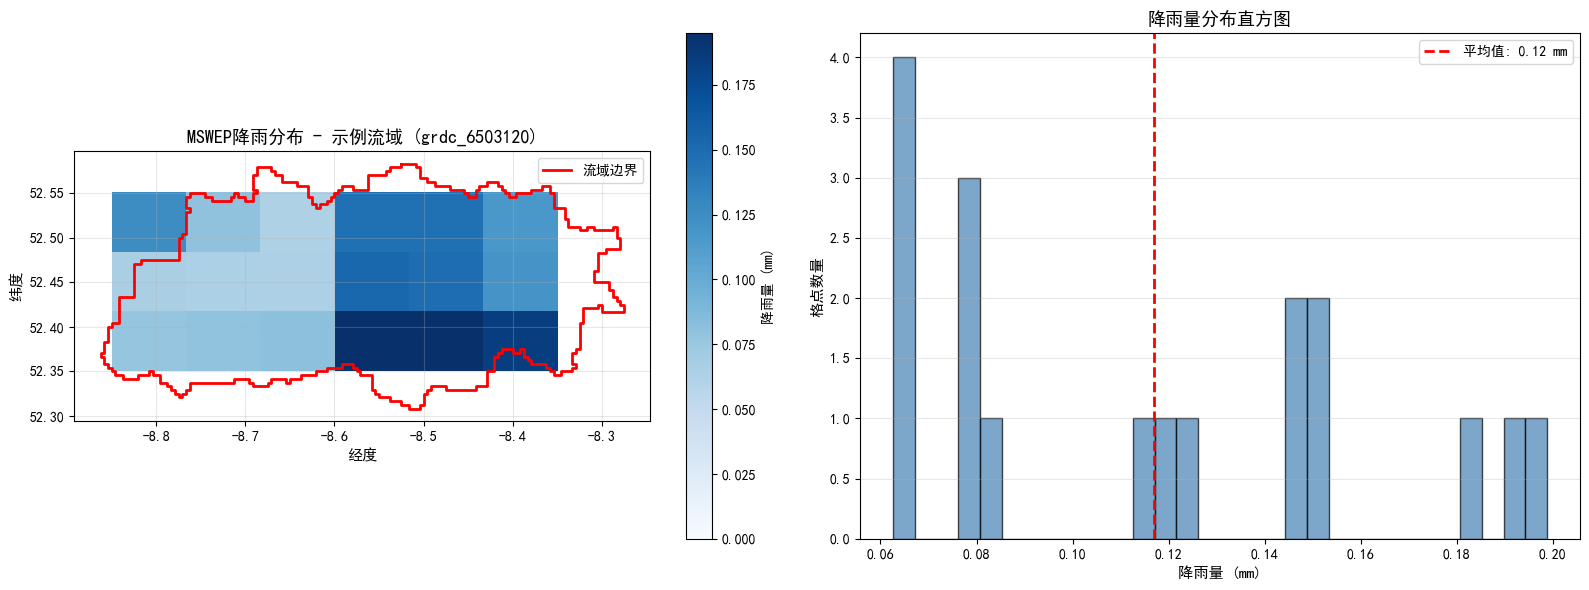


✓ MSWEP数据可视化完成


In [12]:
# ============ 配置 ============
# 修改为实际下载的MSWEP NetCDF文件路径
mswep_file = "/ftproot/mswep_3h/NRT/3hourly/2021303.12.nc"  # 这里选择一个文件作为示例
# ==============================

try:
    # 1. 使用xarray读取MSWEP NetCDF文件
    ds = xr.open_dataset(mswep_file)
    
    print("MSWEP数据集信息:")
    print(ds)
    
    # 2. 自动检测坐标和降雨变量名称
    # MSWEP可能使用 'lat'/'latitude' 和 'lon'/'longitude'
    lat_names = ['lat', 'latitude', 'y']
    lon_names = ['lon', 'longitude', 'x']
    
    lat_name = None
    lon_name = None
    
    for name in lat_names:
        if name in ds.coords or name in ds.dims:
            lat_name = name
            break
    
    for name in lon_names:
        if name in ds.coords or name in ds.dims:
            lon_name = name
            break
    
    if not lat_name or not lon_name:
        raise ValueError(f"无法识别经纬度坐标。可用坐标: {list(ds.coords)}")
    
    print(f"\n检测到坐标: 经度='{lon_name}', 纬度='{lat_name}'")
    
    # 3. 识别降雨变量（通常是 'precipitation' 或 'precip'）
    prcp_names = ['precipitation', 'precip', 'tp', 'prcp']
    prcp_var = None
    
    for name in prcp_names:
        if name in ds.data_vars:
            prcp_var = name
            break
    
    if not prcp_var:
        # 如果没找到，使用第一个数据变量
        prcp_var = list(ds.data_vars)[0]
    
    print(f"检测到降雨变量: '{prcp_var}'")
    
    # 4. 获取示例流域的边界
    minx, miny, maxx, maxy = example_basin.total_bounds
    
    print(f"\n示例流域边界:")
    print(f"  经度: [{minx:.4f}, {maxx:.4f}]")
    print(f"  纬度: [{miny:.4f}, {maxy:.4f}]")
    
    # 5. 裁剪到流域范围
    # 需要注意MSWEP的经纬度可能是递增或递减的
    lats = ds[lat_name].values
    lons = ds[lon_name].values
    
    # 判断纬度是否递减
    if lats[0] > lats[-1]:
        # 纬度递减（从北到南）
        ds_cropped = ds.sel({
            lat_name: slice(maxy, miny),
            lon_name: slice(minx, maxx)
        })
    else:
        # 纬度递增（从南到北）
        ds_cropped = ds.sel({
            lat_name: slice(miny, maxy),
            lon_name: slice(minx, maxx)
        })
    
    # 6. 提取降雨数据
    prcp_data = ds_cropped[prcp_var].values
    
    # 如果有时间维度，取第一个时间步
    if prcp_data.ndim == 3:
        prcp_data = prcp_data[0]
    
    # 获取裁剪后的经纬度
    lats_cropped = ds_cropped[lat_name].values
    lons_cropped = ds_cropped[lon_name].values
    
    print(f"\n裁剪后的数据:")
    print(f"  数据形状: {prcp_data.shape}")
    print(f"  经度范围: [{lons_cropped.min():.4f}, {lons_cropped.max():.4f}]")
    print(f"  纬度范围: [{lats_cropped.min():.4f}, {lats_cropped.max():.4f}]")
    print(f"  降雨统计: min={np.nanmin(prcp_data):.2f}, max={np.nanmax(prcp_data):.2f}, mean={np.nanmean(prcp_data):.2f} mm")
    
    # 7. 可视化
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 左图: 降雨分布
    ax1 = axes[0]
    extent = [lons_cropped.min(), lons_cropped.max(), lats_cropped.min(), lats_cropped.max()]
    
    im1 = ax1.imshow(prcp_data, cmap='Blues', extent=extent, origin='upper',
                     vmin=0, vmax=np.nanpercentile(prcp_data[prcp_data > 0], 95) if np.any(prcp_data > 0) else 10)
    plt.colorbar(im1, ax=ax1, label="降雨量 (mm)")
    
    # 叠加流域边界
    for geom in example_basin.geometry:
        if geom.geom_type == 'Polygon':
            x, y = geom.exterior.xy
            ax1.plot(x, y, 'r-', linewidth=2, label='流域边界')
        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                ax1.plot(x, y, 'r-', linewidth=2)
    
    ax1.set_title(f"MSWEP降雨分布 - 示例流域 ({example_basin_id})", fontsize=13, fontweight='bold')
    ax1.set_xlabel("经度", fontsize=11)
    ax1.set_ylabel("纬度", fontsize=11)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 右图: 降雨直方图
    ax2 = axes[1]
    valid_data = prcp_data[~np.isnan(prcp_data)]
    valid_data = valid_data[valid_data > 0]
    
    if len(valid_data) > 0:
        ax2.hist(valid_data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        ax2.set_xlabel('降雨量 (mm)', fontsize=11)
        ax2.set_ylabel('格点数量', fontsize=11)
        ax2.set_title('降雨量分布直方图', fontsize=13, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.axvline(np.mean(valid_data), color='red', linestyle='--',
                    linewidth=2, label=f'平均值: {np.mean(valid_data):.2f} mm')
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, '无有效降雨数据', ha='center', va='center', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ MSWEP数据可视化完成")
    
    # 关闭数据集
    ds.close()
    
except FileNotFoundError:
    print(f"✗ 错误: 未找到文件 {mswep_file}")
    print(f"  请确认MSWEP数据文件路径是否正确")
except Exception as e:
    print(f"✗ 可视化时出错: {e}")
    import traceback
    traceback.print_exc()